# Modelado

En este notebook se carga el dataset final, se separa la variable objetivo `has_chart_hits`, se divide en train/test con estratificacion y se preparan los datos para entrenar los modelos comparativos.

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Carga del dataset final
df = pd.read_csv("../data/features_final.csv")

# Separacion de variables predictoras y objetivo
X = df.drop(columns=["has_chart_hits"])
y = df["has_chart_hits"]

# Nos quedamos con las variables numericas para poder escalar y modelar
X = X.select_dtypes(include="number")

print("Dimensiones de X:", X.shape)
print("Distribucion de y:")
print(y.value_counts(normalize=True).mul(100).round(2))

Dimensiones de X: (148473, 7)
Distribucion de y:
has_chart_hits
0    89.75
1    10.25
Name: proportion, dtype: float64


In [3]:
# Division estratificada en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Escalado de variables numericas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Primeras 7 columnas escaladas:", X_train.columns[:7].tolist())

Train shape: (118778, 7) (118778,)
Test shape: (29695, 7) (29695,)
Primeras 5 columnas escaladas: ['followers', 'popularity', 'degree', 'degree_centrality', 'clustering', 'pagerank', 'community']


## 2. Modelo 1: Random Forest mixto

Se entrena un Random Forest con `random_state=42` y `class_weight="balanced"` para tratar el desbalance de clases. Aunque el modelo no necesita escalado, se mantiene `StandardScaler` porque forma parte del flujo solicitado y deja el notebook homogéneo con otros modelos.

Matriz de confusion:
[[26385   265]
 [  803  2242]]

Classification report:
              precision    recall  f1-score   support

           0     0.9705    0.9901    0.9802     26650
           1     0.8943    0.7363    0.8076      3045

    accuracy                         0.9640     29695
   macro avg     0.9324    0.8632    0.8939     29695
weighted avg     0.9627    0.9640    0.9625     29695



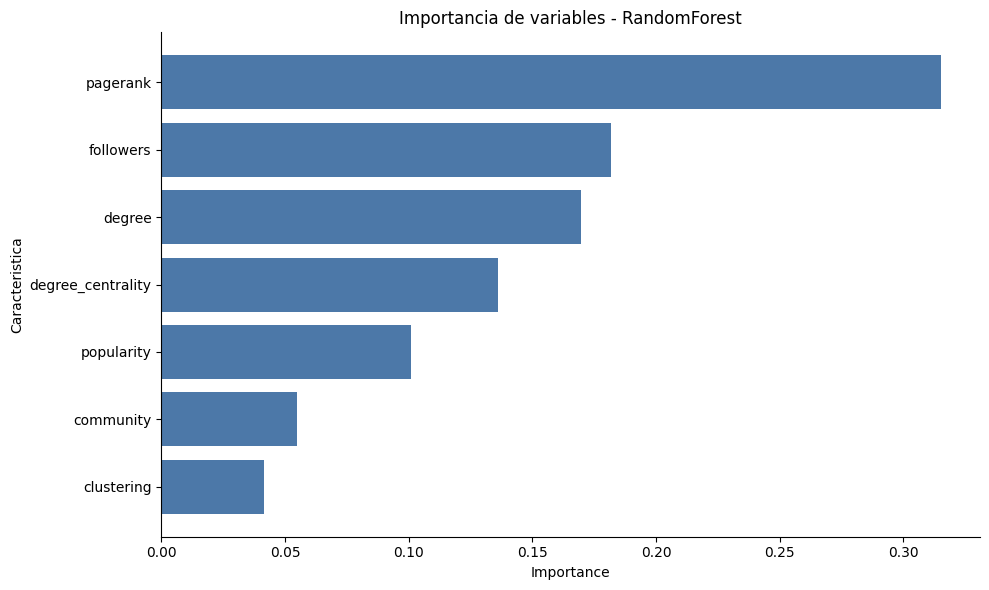

In [ ]:
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=300,
    n_jobs=-1,
)

rf_model.fit(X_train_scaled, y_train)
# El modelo queda entrenado y listo para su evaluacion en el notebook comparativo.

## 3. Modelo 2: aproximación puramente relacional

En este segundo experimento se eliminan explícitamente las variables nativas del artista (`followers` y `popularity`) para evaluar únicamente la capacidad predictiva de las métricas de red.

Matriz de confusion:
[[26088   562]
 [  814  2231]]

Classification report:
              precision    recall  f1-score   support

           0     0.9697    0.9789    0.9743     26650
           1     0.7988    0.7327    0.7643      3045

    accuracy                         0.9537     29695
   macro avg     0.8843    0.8558    0.8693     29695
weighted avg     0.9522    0.9537    0.9528     29695



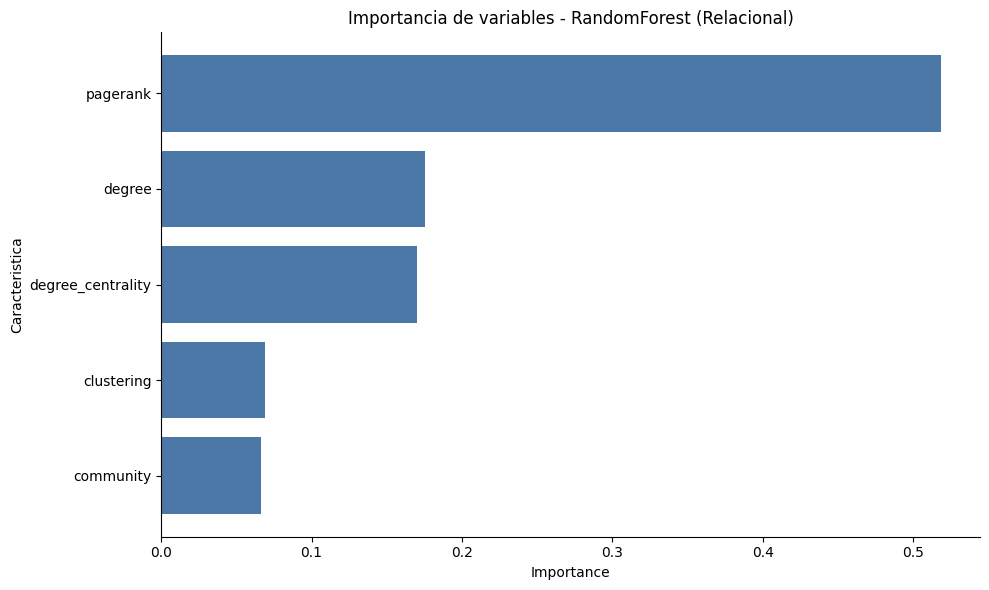

In [ ]:
# Reutilizamos los datos del modelo anterior, pero eliminamos las columnas nativas
X_train_relacional = X_train.drop(columns=['followers', 'popularity'])
X_test_relacional = X_test.drop(columns=['followers', 'popularity'])

# Volvemos a escalar con las variables relacionales
scaler_relacional = StandardScaler()
X_train_rel_scaled = scaler_relacional.fit_transform(X_train_relacional)
X_test_rel_scaled = scaler_relacional.transform(X_test_relacional)

# Entrenamos el Modelo 2: puramente relacional
rf_model_rel = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_rel.fit(X_train_rel_scaled, y_train)
# El modelo queda entrenado y listo para su evaluacion en el notebook comparativo.

## 4. Modelo 3: red neuronal puramente relacional

Este tercer experimento mantiene las mismas variables relacionales y sustituye el Random Forest por una red neuronal MLP para comparar el comportamiento de un modelo no lineal distinto sobre el mismo problema desbalanceado.

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    early_stopping=True,
    random_state=42,
)

mlp_model.fit(X_train_rel_scaled, y_train)
# El modelo queda entrenado y listo para su evaluacion en el notebook comparativo.

Matriz de confusion:
[[26392   258]
 [  881  2164]]

Classification report:
              precision    recall  f1-score   support

           0     0.9677    0.9903    0.9789     26650
           1     0.8935    0.7107    0.7917      3045

    accuracy                         0.9616     29695
   macro avg     0.9306    0.8505    0.8853     29695
weighted avg     0.9601    0.9616    0.9597     29695



## 5. Modelo 4: modelo definitivo mixto

Este modelo reutiliza el mismo flujo de escalado del primer experimento, pero entrena una red neuronal sobre todas las variables disponibles, incluyendo las métricas relacionales y las propiedades nativas del artista.

In [ ]:
mlp_mixed_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    early_stopping=True,
    random_state=42,
)

mlp_mixed_model.fit(X_train_scaled, y_train)
# El modelo queda entrenado y listo para su evaluacion en el notebook comparativo.

Matriz de confusion:
[[26354   296]
 [  792  2253]]

Classification report:
              precision    recall  f1-score   support

           0     0.9708    0.9889    0.9798     26650
           1     0.8839    0.7399    0.8055      3045

    accuracy                         0.9634     29695
   macro avg     0.9274    0.8644    0.8926     29695
weighted avg     0.9619    0.9634    0.9619     29695

